In [1]:
#Preparación del entorno
using Pkg
Pkg.activate("/home/antonibancells/Desktop/Codi/TFM/ProvesModernes")

  Activating project at `~/Desktop/Codi/TFM/ProvesModernes`


La ecuación de Bioheat en régimen estacionario es: $$\alpha\frac{d^2 T}{dz^2}+\frac{T_b-T}{\tau}+\frac{A_0}{\rho c}=0$$
donde $\alpha=\frac{k}{\rho c}$, $\tau=\frac{\rho c}{\rho_b c_b \omega_b}$.

La derivada segunda se aproxima mediante la expresión: $$\frac{d^2 T}{dz^2} \approx \frac{T_{j-1}-2T_j+t_{j+1}}{2 \Delta z^2}$$
donde $T_j=T(j\Delta z)$. En consecuencia, resulta la ecuación lineal: $$-T_{j-1}+\left(2+\frac{\Delta z^2}{\alpha \tau}\right)T_j-T_{j+1}=\frac{\Delta z^2}{\alpha}\left(\frac{T_b}{\tau}+ \frac{A_0}{\rho c}\right)=F$$
Esta ecuación es válida en los nodos $j=2,\dots,N-1$. En los nodos $j=1$ y $j=N$ hay que tener en cuenta las condiciones de contorno

En el nodo $j=1$ la ecuación se convierte en $$-T_0+\left(2+\frac{\Delta z^2}{\alpha \tau}\right)T_1-T_2=F$$
Se necesita un valor de $T_0$ que tiene que estimarse a partir de la condición de contorno de Robin:
$$-k\frac{dT(0)}{dz}=h(T_e-T_0)$$
También es necesaria una aproximación de la derivada en $z=0$ que sea de segundo orden, como también lo es la de la derivada segunda: $$\frac{dT(0)}{dz}=\frac{-3T_0+4T_1-T_2}{2 \Delta z}$$
Si se substituye esta expressión en la condición de contorno se obtiene una expresión para $T_0$:
$$T_0=\frac{4T_1-T_2+\epsilon T_e}{3+\epsilon}$$ donde $\epsilon=\frac{2h\Delta z}{k}$.  Si se substituye en la ecuación del nodo, se obtiene:$$\left(\frac{2+2\epsilon}{3+\epsilon}+\frac{\Delta z^2}{\alpha \tau}\right)T_1-\left(\frac{2+\epsilon}{3+\epsilon} \right)T_2=\frac{\epsilon}{3+\epsilon}T_e+F$$

En el nodo $j=N$ la ecuación se convierte en $$-T_{N-1}+\left(2+\frac{\Delta z^2}{\alpha \tau}\right)T_N-T_{N+1}=F$$
El valor de $T_{N+1}$ se obtiene mediante la condición de Dirichlet de que la temperatura en el otro extremo es $T_b$. De esta manera, la ecuación de este nodo se convierte en: 
$$-T_{N-1}+\left(2+\frac{\Delta z^2}{\alpha \tau}\right)T_N=T_b+F$$

In [2]:
#Librerías necesarias
using Plots
using LinearAlgebra

#  Parámetros del modelo
N = 99                  # Número de nodos (sólo los internos). Los nodos externos són z=0 y z=L
L = 0.05                # Profundidad del tejido
dz = L / (N + 1)        # Paso de la malla

k = 0.5                 # Conductivitat tèrmica (W/m·K) del tejido
wb = 0.0005             # Perfusión sangre (1/s)
rhob = 1060             # Densidad sangre (kg/m3)
rho = 1100              # Densidad tejido (Kg/m3)
cb = 3600               # Calor específico sangre (J/kg·K)
c  = 3600               # Calor específico tejido (J/kg·K)

Tb = 37.0       # Temperatura arterial (ºC)
A0 = 420.0      # Metabolismo basal(W/m3)

h = 10 #Coeficiente de transferencia de calor convectivo (W/m2·C)
Te=20 

# Variables auxiliares
alfa=k/(rho*c)
tau=(rho*c)/(rhob*cb*wb)
phi=dz^2/(alfa*tau)
F = phi * Tb + (dz^2 * A0 / k)
epsilon=2*h*dz/k
c1=(2+2*epsilon)/(3+epsilon)+phi
c2=(2+epsilon)/(3+epsilon)

0.6688741721854304

Resolviendo sistema lineal directo...


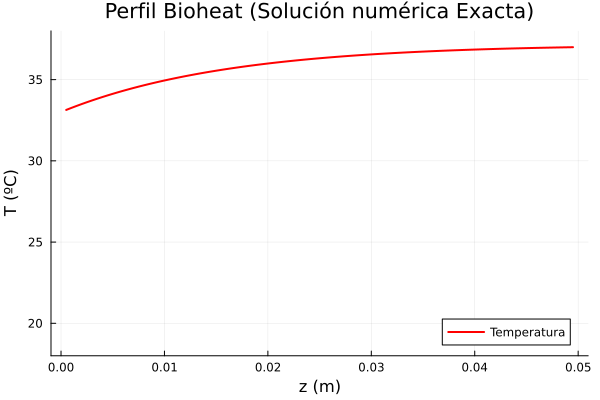

✅ Proceso completado.
Temp. Superfície: 33.13 ºC
Temp. Interior: 36.99 ºC


In [3]:
# CONSTRUCCIÓN DE LA MATRIZ Y TÉRMINOS INDEPENDIENTES
M = zeros(N, N)
b = zeros(N)

for j in 1:N
    # Terme independent (Vector b)
    if j == 1
        b[j] = (epsilon / (3 + epsilon)) * Te + F
        M[j, j] = c1
        M[j, j+1] = -c2
    elseif j == N
        b[j] = Tb + F
        M[j, j] = 2.0 + phi
        M[j, j-1] = -1.0
    else
        b[j] = F
        M[j, j] = 2.0 + phi
        M[j, j-1] = -1.0
        M[j, j+1] = -1.0
    end
end

# RESOLUCIÓN DIRECTA
println("Resolviendo sistema lineal directo...")
T_fisica = M \ b

# GRÁFICA
eix_z = [j * dz for j in 1:N]
p = plot(eix_z, T_fisica, 
     title="Perfil Bioheat (Solución numérica Exacta)",
     label="Temperatura", lw=2, color=:red,
     xlabel="z (m)", ylabel="T (ºC)",
     grid=true, ylims=(Te-2, 38))

display(p)

println("✅ Proceso completado.")
println("Temp. Superfície: ", round(T_fisica[1], digits=2), " ºC")
println("Temp. Interior: ", round(T_fisica[end], digits=2), " ºC")